In [1]:
# Cell 1: Environment Locking & Isolation (Manifesto Rule 4.1)
import sys
from pathlib import Path

expected_env_name = "scotland-ai-split-zones"
actual_path = Path(sys.executable)

assert expected_env_name in str(actual_path), (
    f"Kernel mismatch. Expected environment containing '{expected_env_name}', "
    f"but running in {actual_path}. Run `uv run jupyter lab` from the project root."
)
print(f"Environment verified: {actual_path}")

Environment verified: /home/ndrew/scotland-ai-split-zones/.venv/bin/python3


In [2]:
# Cell 2: Imports and Config Loading
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

ROOT_DIR = Path.cwd().parent
DATA_INTERMEDIATE = ROOT_DIR / "data" / "intermediate"
FIGURES_DIR = ROOT_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Cell 3: Parquet Handoff (Manifesto Rule 4.2)
# Read validated inputs from Notebook 01 and Notebook 02.

site_register_path = DATA_INTERMEDIATE / "candidate_site_register.parquet"
sensitivity_path = DATA_INTERMEDIATE / "workload_response_sensitivity.parquet"

if not site_register_path.exists() or not sensitivity_path.exists():
    raise FileNotFoundError("Parquet handoff failed. Please run Notebooks 01 and 02 to completion.")

site_register = pl.read_parquet(site_register_path)
sensitivity_df = pl.read_parquet(sensitivity_path)

print(f"Loaded {len(site_register)} sites and {len(sensitivity_df)} sensitivity scenarios.")

Loaded 7 sites and 48 sensitivity scenarios.


In [4]:
# Cell 4: Residual Grid Burden Calculation (Scaled to Site Capacity)
# Manifesto Rule: Mechanism Before Model. 
# We assume the AI campus draws power equal to its planning capacity.

# Join site capacity AND constraint direction to use as the baseline AI load
burden_df = site_register.select(["site_name", "capacity_mw", "constraint_direction"]).join(
    sensitivity_df, how="cross"
).with_columns(
    # The baseline AI load IS the site's planning capacity
    pl.col("capacity_mw").alias("baseline_ai_load_mw"),
    
    # Calculate flexible response based on the actual site capacity
    (pl.col("capacity_mw") * pl.col("schedulable_fraction") * pl.col("duration_compatibility_factor")).alias("flexible_response_mw")
).with_columns(
    # Residual Burden = Total Load - Flexible Response
    (pl.col("baseline_ai_load_mw") - pl.col("flexible_response_mw")).alias("residual_grid_burden_mw")
).select([
    "site_name",
    "constraint_direction",
    "capacity_mw",
    "baseline_ai_load_mw",
    "notice_period_h",
    "schedulable_fraction",
    "event_duration_h",
    "flexible_response_mw",
    "residual_grid_burden_mw"
])

# Assertions Protect Physics
assert (burden_df["residual_grid_burden_mw"] >= 0).all(), "Physical violation: Residual burden cannot be negative."

print("Residual grid burden calculated for all scenarios (scaled to site capacity).")
print(burden_df.head(3))

Residual grid burden calculated for all scenarios (scaled to site capacity).
shape: (3, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ site_name ┆ constrain ┆ capacity_ ┆ baseline_ ┆ … ┆ schedulab ┆ event_dur ┆ flexible_ ┆ residual │
│ ---       ┆ t_directi ┆ mw        ┆ ai_load_m ┆   ┆ le_fracti ┆ ation_h   ┆ response_ ┆ _grid_bu │
│ str       ┆ on        ┆ ---       ┆ w         ┆   ┆ on        ┆ ---       ┆ mw        ┆ rden_mw  │
│           ┆ ---       ┆ f64       ┆ ---       ┆   ┆ ---       ┆ i64       ┆ ---       ┆ ---      │
│           ┆ str       ┆           ┆ f64       ┆   ┆ f64       ┆           ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ Whitelee  ┆ export    ┆ 539.0     ┆ 539.0     ┆ … ┆ 0.0       ┆ 2         ┆ 0.0       ┆ 539.0    │
│ Wind Farm ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │


In [5]:
# Cell 5: Parquet Handoff (Save for Notebook 05)
output_path = DATA_INTERMEDIATE / "residual_grid_burden.parquet"
burden_df.write_parquet(output_path)
print(f"Saved residual grid burden matrix to {output_path}")

Saved residual grid burden matrix to /home/ndrew/scotland-ai-split-zones/data/intermediate/residual_grid_burden.parquet


Saved figure to /home/ndrew/scotland-ai-split-zones/figures/residual_burden_mismatch_comparison.png


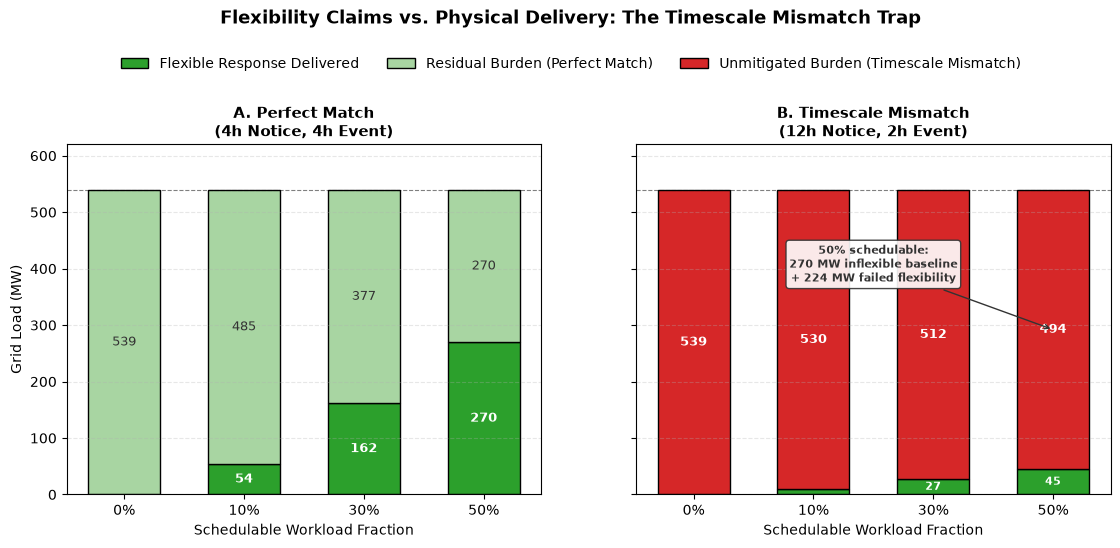

In [6]:
# Cell 6: Tufte-Compliant Visualization (Timescale Mismatch)
# Manifesto Rule 9.3: Show causation, comparison, and context.
# Stacked bars: Green = actual flexible response delivered.
# Chart A: Light green residual (match is perfect, burden is manageable).
# Chart B: Red residual (mismatch means the flexibility claim fails physically).

import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Scenario A: Perfect Match (4h notice, 4h event)
scenario_a = burden_df.filter(
    (pl.col("notice_period_h") == 4) & 
    (pl.col("event_duration_h") == 4) &
    (pl.col("site_name") == "Whitelee Wind Farm")
).sort("schedulable_fraction")

# Scenario B: Timescale Mismatch (12h notice, 2h event)
scenario_b = burden_df.filter(
    (pl.col("notice_period_h") == 12) & 
    (pl.col("event_duration_h") == 2) &
    (pl.col("site_name") == "Whitelee Wind Farm")
).sort("schedulable_fraction")

# Safety check to ensure data exists before plotting
if scenario_a.is_empty() or scenario_b.is_empty():
    print("WARNING: One of the scenarios is empty. Check filter conditions.")
    print(f"Scenario A rows: {len(scenario_a)}")
    print(f"Scenario B rows: {len(scenario_b)}")
else:
    x_labels = ["0%", "10%", "30%", "50%"]
    x = range(len(x_labels))
    width = 0.6

    # --- Chart A: Perfect Match ---
    ax1 = axes[0]
    residual_a = scenario_a["residual_grid_burden_mw"].to_list()
    baseline_a = scenario_a["baseline_ai_load_mw"].to_list()[0] # Dynamic baseline
    flex_a = [baseline_a - r for r in residual_a]

    ax1.bar(x, flex_a, width, color="#2ca02c", edgecolor="black")
    ax1.bar(x, residual_a, width, bottom=flex_a, color="#a8d5a2", edgecolor="black")

    ax1.set_title("A. Perfect Match\n(4h Notice, 4h Event)", fontsize=11, fontweight="bold")
    ax1.set_ylabel("Grid Load (MW)")
    ax1.set_xticks(x)
    ax1.set_xticklabels(x_labels)
    ax1.set_xlabel("Schedulable Workload Fraction")
    ax1.set_ylim(0, baseline_a * 1.15)
    ax1.axhline(baseline_a, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax1.grid(axis="y", linestyle="--", alpha=0.3)

    for i in range(len(x)):
        if flex_a[i] > (baseline_a * 0.05):
            ax1.text(i, flex_a[i] / 2, f"{flex_a[i]:.0f}", ha="center", va="center", fontsize=9, fontweight="bold", color="white")
        if residual_a[i] > (baseline_a * 0.05):
            ax1.text(i, flex_a[i] + residual_a[i] / 2, f"{residual_a[i]:.0f}", ha="center", va="center", fontsize=9, color="#333333")

    # --- Chart B: Timescale Mismatch ---
    ax2 = axes[1]
    residual_b = scenario_b["residual_grid_burden_mw"].to_list()
    baseline_b = scenario_b["baseline_ai_load_mw"].to_list()[0] # Dynamic baseline
    flex_b = [baseline_b - r for r in residual_b]

    ax2.bar(x, flex_b, width, color="#2ca02c", edgecolor="black")
    ax2.bar(x, residual_b, width, bottom=flex_b, color="#d62728", edgecolor="black")

    ax2.set_title("B. Timescale Mismatch\n(12h Notice, 2h Event)", fontsize=11, fontweight="bold")
    ax2.set_xticks(x)
    ax2.set_xticklabels(x_labels)
    ax2.set_xlabel("Schedulable Workload Fraction")
    ax2.set_ylim(0, baseline_b * 1.15)
    ax2.axhline(baseline_b, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax2.grid(axis="y", linestyle="--", alpha=0.3)

    for i in range(len(x)):
        if flex_b[i] > (baseline_b * 0.05):
            ax2.text(i, flex_b[i] / 2, f"{flex_b[i]:.0f}", ha="center", va="center", fontsize=8, fontweight="bold", color="white")
        if residual_b[i] > (baseline_b * 0.05):
            ax2.text(i, flex_b[i] + residual_b[i] / 2, f"{residual_b[i]:.0f}", ha="center", va="center", fontsize=9, fontweight="bold", color="white")
    
    # ADD THIS: Annotation explaining the burden composition at 50% schedulable
    # At 50% schedulable (index 3), show the breakdown
    idx_50pct = 3  # Index for 50% schedulable fraction
    inflexible_baseline = baseline_b * 0.5  # 50% is never flexible
    failed_flexibility = residual_b[idx_50pct] - inflexible_baseline
    
    ax2.annotate(
        f"50% schedulable:\n{inflexible_baseline:.0f} MW inflexible baseline\n+ {failed_flexibility:.0f} MW failed flexibility",
        xy=(idx_50pct, flex_b[idx_50pct] + residual_b[idx_50pct] * 0.5),  # Point to middle of red bar
        xytext=(idx_50pct - 1.5, baseline_b * 0.7),  # Position text to the left
        fontsize=8,
        fontweight="bold",
        color="#333333",
        ha="center",
        arrowprops=dict(arrowstyle="->", color="#333333", lw=1.0),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#333333", alpha=0.9)
    )
    # --- Unified, Explicit Legend ---
    legend_elements = [
        mpatches.Patch(facecolor="#2ca02c", edgecolor="black", label="Flexible Response Delivered"),
        mpatches.Patch(facecolor="#a8d5a2", edgecolor="black", label="Residual Burden (Perfect Match)"),
        mpatches.Patch(facecolor="#d62728", edgecolor="black", label="Unmitigated Burden (Timescale Mismatch)")
    ]

    fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=False, fontsize=10)

    plt.suptitle("Flexibility Claims vs. Physical Delivery: The Timescale Mismatch Trap", fontsize=13, fontweight="bold", y=1.12)
    
    # FIX: Use explicit subplots_adjust instead of tight_layout to prevent Matplotlib from cropping the second chart
    fig.subplots_adjust(top=0.85, bottom=0.15, left=0.08, right=0.95)

    fig_path = FIGURES_DIR / "residual_burden_mismatch_comparison.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to {fig_path}")
    plt.show()